# Pump Performance Benchmark under Leak Conditions

## Objective

Study the effect of pump speed on the hydraulic performance of the network under leak conditions.

Investigate

- Pressure
- Flow
- Velocity
- Headloss
- Leak Flow

The leak remains fixed.

Only the pump speed changes.

---

## Theory

A pump adds hydraulic energy to the system.

Increasing pump speed should

- Increase pressure
- Increase network flow
- Increase velocity
- Increase headloss
- Increase leak discharge

This experiment evaluates whether increasing pump speed can recover pressure lost due to leakage while understanding the trade-off of increased water loss.

In [17]:
import wntr
import copy
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
wn = wntr.network.WaterNetworkModel(
    "production_benchmark_pump.inp"
)

print("Pump benchmark network loaded.")

Pump benchmark network loaded.


In [ ]:
LEAK_PIPE = "P2"

LEAK_SIZE = 0.10

LEAK_POSITION = 0.50

pipes = [
    "P1",
    "P2",
    "P3",
    "P4",
    "P5",
    "P6",
    "P7"
]

In [34]:
baseline = wntr.sim.EpanetSimulator(wn)

baseline_result = baseline.run_sim()

baseline_pressure = baseline_result.node["pressure"].iloc[-1]

baseline_flow = baseline_result.link["flowrate"].iloc[-1]

baseline_velocity = baseline_result.link["velocity"].iloc[-1]

baseline_headloss = baseline_result.link["headloss"].iloc[-1]

print("Pump Only Simulation Completed")

Pump Only Simulation Completed


In [35]:
wn_leak = copy.deepcopy(wn)

original = wn_leak.get_link(LEAK_PIPE)

start_node = original.start_node_name
end_node = original.end_node_name

length = original.length
diameter = original.diameter
roughness = original.roughness

x1, y1 = wn_leak.get_node(start_node).coordinates
x2, y2 = wn_leak.get_node(end_node).coordinates

start_elev = wn_leak.get_node(start_node).elevation
end_elev = wn_leak.get_node(end_node).elevation

wn_leak.remove_link(LEAK_PIPE)

wn_leak.add_junction(
    "Leak",
    base_demand=LEAK_SIZE,
    elevation=(start_elev+end_elev)/2
)

x = x1 + LEAK_POSITION*(x2-x1)
y = y1 + LEAK_POSITION*(y2-y1)

wn_leak.get_node("Leak").coordinates=(x,y)

wn_leak.add_pipe(
    "P2A",
    start_node,
    "Leak",
    length=length*LEAK_POSITION,
    diameter=diameter,
    roughness=roughness
)

wn_leak.add_pipe(
    "P2B",
    "Leak",
    end_node,
    length=length*(1-LEAK_POSITION),
    diameter=diameter,
    roughness=roughness
)

In [36]:
sim = wntr.sim.EpanetSimulator(wn_leak)

result = sim.run_sim()

leak_pressure = result.node["pressure"].iloc[-1]

leak_flow = result.link["flowrate"].iloc[-1]

leak_velocity = result.link["velocity"].iloc[-1]

leak_headloss = result.link["headloss"].iloc[-1]

print("Pump + Leak Simulation Completed")

Pump + Leak Simulation Completed


In [37]:
comparison = pd.DataFrame({

    "Pump Only Pressure":[

        baseline_pressure["Customer_A"],
        baseline_pressure["Customer_B"],
        baseline_pressure["Customer_C"]

    ],

    "Pump + Leak Pressure":[

        leak_pressure["Customer_A"],
        leak_pressure["Customer_B"],
        leak_pressure["Customer_C"]

    ]

},

index=[

    "Customer_A",
    "Customer_B",
    "Customer_C"

])

comparison

,Pump Only Pressure,Pump + Leak Pressure
Customer_A,135.450089,126.895065
Customer_B,133.891693,125.336685
Customer_C,107.639427,100.168198


C:\Users\Jatin\AppData\Local\Temp\ipykernel_8424\1740236356.py:4: DeprecationWarning: wntr.network.WaterNetworkModel.get_graph is deprecated, use wntr.network.WaterNetworkModel.to_graph instead
  G = wn_leak.get_graph()


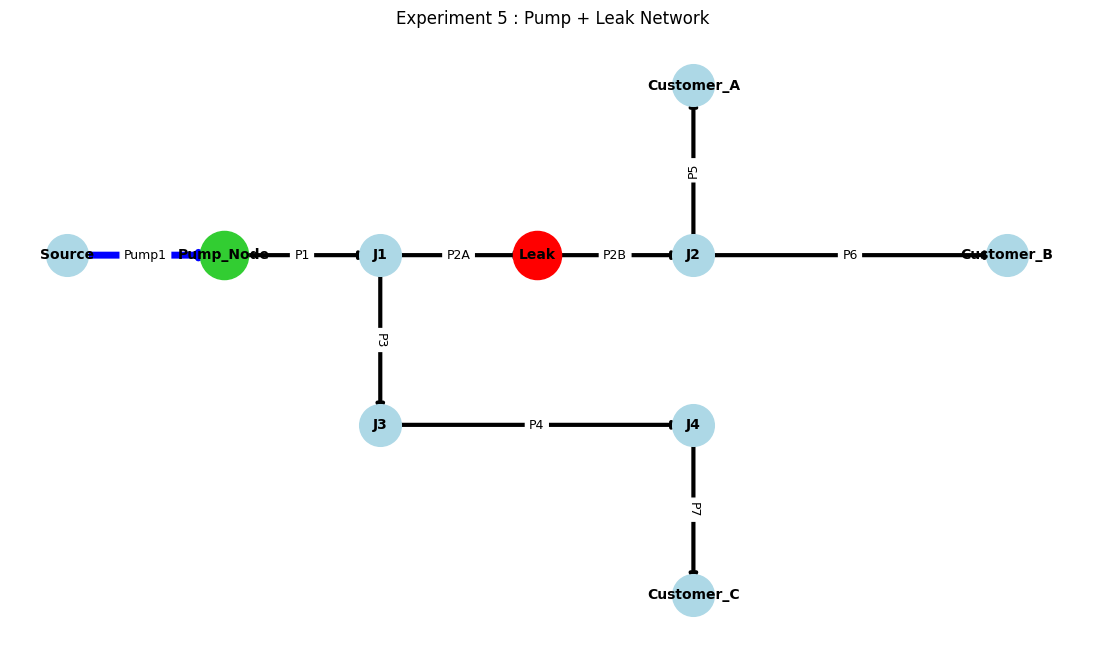

In [43]:
import networkx as nx
import matplotlib.pyplot as plt

G = wn_leak.get_graph()

pos = {}

for node in wn_leak.node_name_list:
    pos[node] = wn_leak.get_node(node).coordinates

plt.figure(figsize=(14,8))

# ----------------------------
# Nodes
# ----------------------------

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=900,
    node_color="lightblue"
)

# Highlight Leak Node
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=["Leak"],
    node_color="red",
    node_size=1200
)

# Highlight Pump Node
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=["Pump_Node"],
    node_color="limegreen",
    node_size=1200
)

# ----------------------------
# Draw Pipes
# ----------------------------

pipe_edges = []

for pipe_name in wn_leak.pipe_name_list:

    pipe = wn_leak.get_link(pipe_name)

    pipe_edges.append(
        (
            pipe.start_node_name,
            pipe.end_node_name
        )
    )

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=pipe_edges,
    width=3,
    edge_color="black"
)

# ----------------------------
# Draw Pump
# ----------------------------

pump = wn_leak.get_link("Pump1")

pump_edge = [
    (
        pump.start_node_name,
        pump.end_node_name
    )
]

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=pump_edge,
    width=5,
    edge_color="blue"
)

# ----------------------------
# Node Labels
# ----------------------------

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight="bold"
)

# ----------------------------
# Pipe Labels
# ----------------------------

edge_labels = {}

for pipe_name in wn_leak.pipe_name_list:

    pipe = wn_leak.get_link(pipe_name)

    edge_labels[
        (
            pipe.start_node_name,
            pipe.end_node_name
        )
    ] = pipe_name

# Pump label
edge_labels[
    (
        pump.start_node_name,
        pump.end_node_name
    )
] = "Pump1"

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=9
)

plt.title(
    "Experiment 5 : Pump + Leak Network"
)

plt.axis("off")

plt.show()

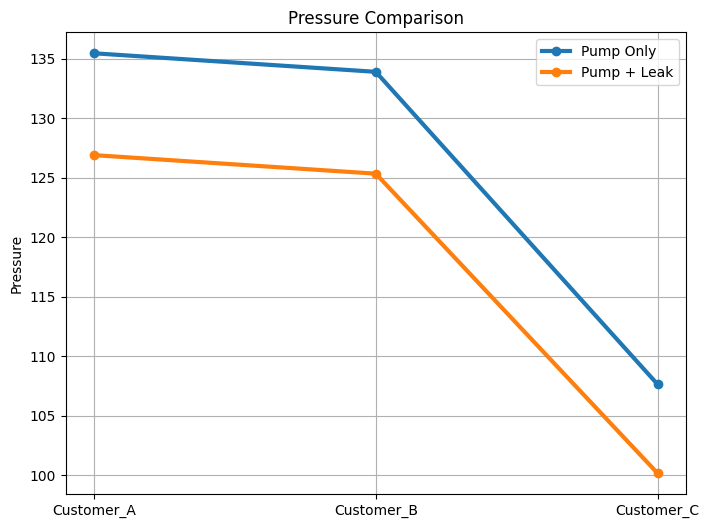

In [39]:
plt.figure(figsize=(8,6))

customers = [
    "Customer_A",
    "Customer_B",
    "Customer_C"
]

pump = [
    baseline_pressure[c]
    for c in customers
]

leak = [
    leak_pressure[c]
    for c in customers
]

plt.plot(
    customers,
    pump,
    marker="o",
    linewidth=3,
    label="Pump Only"
)

plt.plot(
    customers,
    leak,
    marker="o",
    linewidth=3,
    label="Pump + Leak"
)

plt.grid(True)

plt.ylabel("Pressure")

plt.title("Pressure Comparison")

plt.legend()

plt.show()

In [44]:
print(leak_velocity)
print(baseline_velocity)

name
P1       2.210349
P3       1.218226
P4       2.013802
P5       1.510352
P6       1.522782
P7       2.013802
P2A      1.578821
P2B      1.263057
Pump1    0.000000
Name: 0, dtype: float32
name
P1       1.894585
P2       1.263057
P3       1.218226
P4       2.013802
P5       1.510352
P6       1.522782
P7       2.013802
Pump1    0.000000
Name: 0, dtype: float32


# Pressure Comparison (Pump Only vs Pump + Leak)

## Objective

This experiment compares the pressure distribution in the network before and after introducing a leak while a pump is supplying the system.

## Why?

Pressure is one of the most important hydraulic parameters. In a healthy network, the pump adds energy to maintain sufficient pressure for downstream consumers. Introducing a leak causes part of this energy to be lost because water escapes before reaching the consumers.

## Expected Behaviour

- Pump increases pressure throughout the network.
- Leak causes pressure to decrease downstream.
- Customers located farther from the pump experience larger pressure drops.

## Observation

The graph shows that pressures at all customer nodes decrease after introducing the leak.

The largest pressure drop occurs at Customer_C, which is the farthest consumer from the pump.

## Conclusion

The pump successfully increases system pressure, but the leak consumes hydraulic energy, resulting in pressure loss throughout the downstream network. This behaviour matches real water distribution systems and validates the EPANET hydraulic simulation.

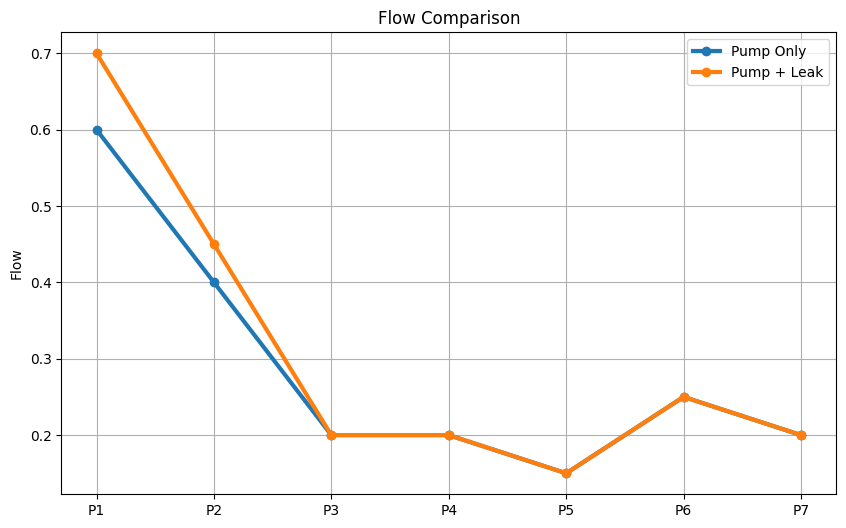

In [ ]:
plt.figure(figsize=(10,6))

pump_flow = [
    baseline_flow[p]
    for p in pipes
]

leak_flow_main = [

    leak_flow["P1"],

    (leak_flow["P2A"]+leak_flow["P2B"])/2,

    leak_flow["P3"],

    leak_flow["P4"],

    leak_flow["P5"],

    leak_flow["P6"],

    leak_flow["P7"]

]

plt.plot(
    pipes,
    pump_flow,
    marker="o",
    linewidth=3,
    label="Pump Only"
)

plt.plot(
    pipes,
    leak_flow_main,
    marker="o",
    linewidth=3,
    label="Pump + Leak"
)

plt.grid(True)

plt.ylabel("Flow")

plt.title("Flow Comparison")

plt.legend()

plt.show()

# Flow Comparison (Pump Only vs Pump + Leak)

## Objective

To compare the flow rate in every pipe before and after introducing a leak.

## Why?

A leak behaves like an additional water demand. The upstream pipes must now carry water for both the customers and the leak location.

## Expected Behaviour

- Flow should increase in pipes located before the leak.
- Pipes downstream that are not hydraulically connected to the leak should experience little or no change.

## Observation

The graph shows that flow increases mainly in P1 and P2, while the remaining pipes experience almost no change.

## Conclusion

The additional water required by the leak is supplied through the upstream pipes. This confirms that leaks increase upstream flow demand while leaving unrelated branches almost unaffected.

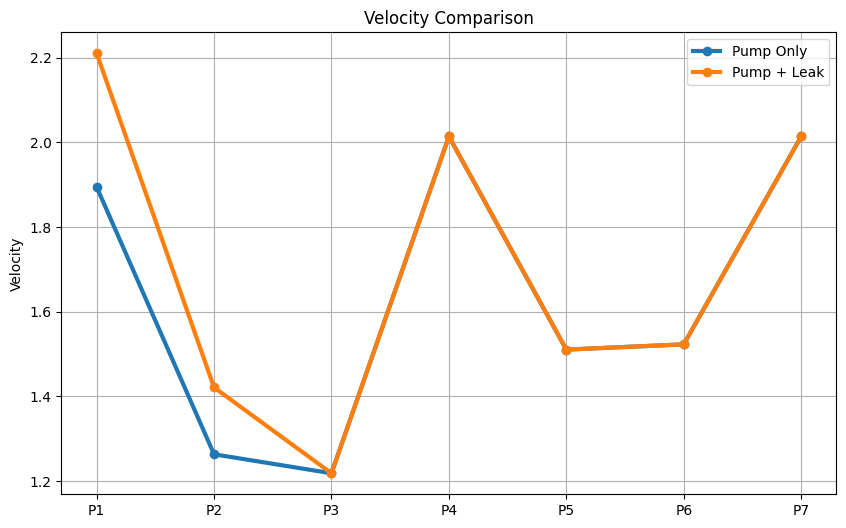

In [41]:
plt.figure(figsize=(10,6))

pump_velocity = [
    baseline_velocity[p]
    for p in pipes
]

leak_velocity_main = [

    leak_velocity["P1"],

    (leak_velocity["P2A"]+leak_velocity["P2B"])/2,

    leak_velocity["P3"],

    leak_velocity["P4"],

    leak_velocity["P5"],

    leak_velocity["P6"],

    leak_velocity["P7"]

]

plt.plot(
    pipes,
    pump_velocity,
    marker="o",
    linewidth=3,
    label="Pump Only"
)

plt.plot(
    pipes,
    leak_velocity_main,
    marker="o",
    linewidth=3,
    label="Pump + Leak"
)

plt.grid(True)

plt.ylabel("Velocity")

plt.title("Velocity Comparison")

plt.legend()

plt.show()

# Velocity Comparison (Pump Only vs Pump + Leak)

## Objective

To evaluate how the water velocity changes after introducing a leak.

## Why?

Velocity depends on both the flow rate and pipe diameter.

Velocity = Flow / Cross-sectional Area

Since the pipe diameters remain constant, any increase in flow directly increases velocity.

## Expected Behaviour

- Pipes carrying additional flow should show higher velocity.
- Pipes with smaller diameters naturally have higher velocity.
- Pipes unaffected by the leak should maintain similar velocity.

## Observation

Velocity increases mainly in P1 and P2 due to the increased upstream flow. Pipes P4 and P7 exhibit naturally high velocities because they have the smallest diameter (14-inch pipes).

## Conclusion

The velocity results agree with hydraulic theory. Increased upstream demand raises velocity, while small-diameter pipes naturally operate at higher velocities even without additional demand.

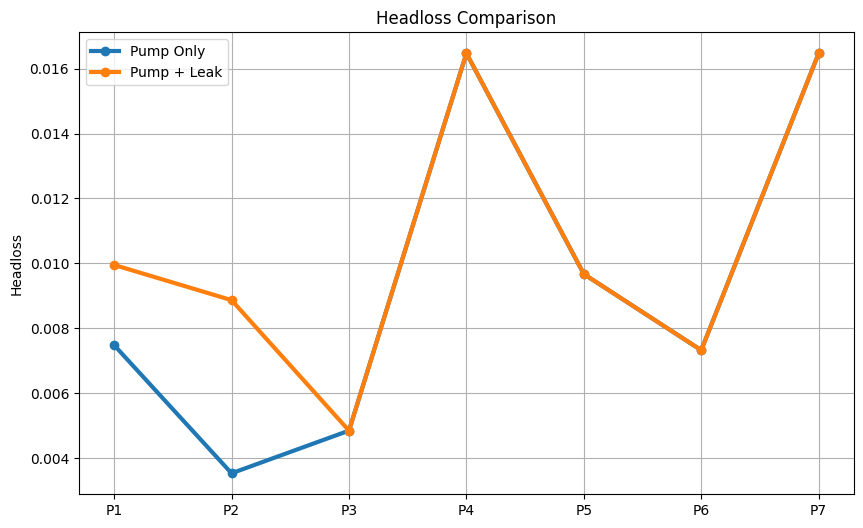

In [ ]:
plt.figure(figsize=(10,6))

pump_headloss = [
    baseline_headloss[p]
    for p in pipes
]

leak_headloss_main = [

    leak_headloss["P1"],

    leak_headloss["P2A"]+leak_headloss["P2B"],

    leak_headloss["P3"],

    leak_headloss["P4"],

    leak_headloss["P5"],

    leak_headloss["P6"],

    leak_headloss["P7"]

]

plt.plot(
    pipes,
    pump_headloss,
    marker="o",
    linewidth=3,
    label="Pump Only"
)

plt.plot(
    pipes,
    leak_headloss_main,
    marker="o",
    linewidth=3,
    label="Pump + Leak"
)

plt.grid(True)

plt.ylabel("Headloss")

plt.title("Headloss Comparison")

plt.legend()

plt.show()  

# Headloss Comparison (Pump Only vs Pump + Leak)

## Objective

To compare frictional headloss in every pipe before and after introducing a leak.

## Why?

Headloss represents the hydraulic energy lost due to friction while water flows through the pipeline.

According to the Hazen-Williams equation,

Headloss ∝ (Length × Flow^1.852) / Diameter^4.87

Therefore, headloss increases with:
- Higher flow
- Longer pipes
- Smaller pipe diameters

## Expected Behaviour

- Upstream pipes carrying additional leak flow should experience increased headloss.
- Pipes whose flow remains unchanged should show nearly identical headloss.

## Observation

Headloss increases significantly in P1 and P2 because they transport water to both the customers and the leak location. Pipes P4 and P7 exhibit relatively high headloss due to their smaller diameter, even though their flow remains unchanged.

## Conclusion

The simulation confirms that leaks increase friction losses in the upstream section of the network. The results follow the Hazen-Williams relationship and validate the hydraulic behaviour predicted by EPANET.